In [ ]:
# epoch影响较大
%run stage1.py \
    --sc_file "/mnt/d/ST_Graduation_Project/database/Wu/CID44971/CID44971_SC.h5ad" \
    --st_file "/mnt/d/ST_Graduation_Project/database/Wu/CID44971/CID44971_ST.h5ad" \
    --n_epochs 50 \
    --resolution 0.5 \
    --loss_type zinb \
    --beta 0.1 \
    --lambda_mmd 1.0 \
    --top_n_per_type 200 \
    --latent_dim 256 \
    --output_dir ./stage1_results/CID44971 \
    --precomputed_marker_file /mnt/d/ST_Graduation_Project/SC_MAP_ST/stage1_results/CID44971/final_genes.txt

Using device: cpu
Stage 1 Training: VAE (SC + ST, Marker Genes)
Configuration:
   Marker genes per type: 200
   Clustering mode: Auto-cluster (Leiden)
   Leiden resolution: 0.5
   Batch size: 256
   Epochs: 50
   Learning rate: 0.001
   Beta (KL weight): 0.1
   Hidden dims: [512, 256]
   Latent dim: 256
   Loss type: ZINB
   Lambda MMD: 1.0
Loading datasets...
   Loading SC: /mnt/d/ST_Graduation_Project/database/GSE203612/NYU_OVCA1/NYU_OVCA1_SC.h5ad
   SC shape: (2372, 14309)
   Loading ST: /mnt/d/ST_Graduation_Project/database/GSE203612/NYU_OVCA1/NYU_OVCA1_ST.h5ad
   ST shape: (1762, 33538)
   Common genes: 14271
   SC final: (2372, 14271)
   ST final: (1762, 14271)
Computing clusters and marker genes...
Starting clustering analysis...


KeyboardInterrupt: 

---

Sample name: CID44971
Stage 1 model: ./stage1_results/CID44971/final_vae.pth
Output directory: ./stage2_results/CID44971/
Device: cpu
Weight threshold: 0.01
Loading pretrained VAE Encoder...
   VAE architecture: 1212 -> 256
   Output type: zinb
   ✓ Loaded 7986 cell cluster labels from checkpoint
Loaded cluster centers: torch.Size([21, 256])
Loaded cluster expressions: torch.Size([21, 1212])
Loaded full gene expressions (count): 21 clusters × 17415 genes
Loaded all genes list: 17415 genes
VAE Encoder loaded: 1212 -> 256
Cell type clusters: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '3', '4', '5', '6', '7', '8', '9']
Marker genes: 1212
Using Stage 1 cluster centers and expressions...
Loaded 21 clusters
Using Stage 1 pretrained cluster data
   Cluster centers: torch.Size([21, 256])
   Cluster expressions: torch.Size([21, 1212])
Loading and processing spatial transcriptomics data...
Loading ST data: /mnt/d/ST_Graduation_Project/database/Wu/CID44971/C

GAT Training:  54%|█████▍    | 271/500 [06:36<05:34,  1.46s/epoch, Total=26.2923, Pearson=0.2873, MSE=449.8700, Cosine=0.2612, Diversity=0.3366, Hetero=0.0946, Proportion=0.5317]


Evaluating model results...
Cells per spot: 10.0
Applying weight threshold: 0.01
   Non-zero elements: 11470 -> 9951 (41.3%)
Saving deconvolution results...
Generating deconvolution expression matrices...
   Marker gene expression...
   Full gene expression...
   Cell type composition...
   Found duplicate celltype names: ['Myeloid', 'Normal Epithelial', 'Cancer Epithelial', 'T-cells']. Merging corresponding cluster columns by summing weights.
   Columns before: 21, after merge: 9
   Saved cell composition (celltype): ./stage2_results/CID44971//CID44971_cell_composition.csv
   Saved cluster composition: ./stage2_results/CID44971//CID44971_cluster_composition.csv

Saving cluster expression data for train.py...
   ✅ Cluster marker gene expression: ./stage2_results/CID44971//CID44971_cluster_marker_expr.csv
   ✅ Cluster full gene expression: ./stage2_results/CID44971//CID44971_cluster_full_expr.csv
   ✅ Celltype-cluster mapping: ./stage2_results/CID44971//CID44971_celltype_cluster_mapping

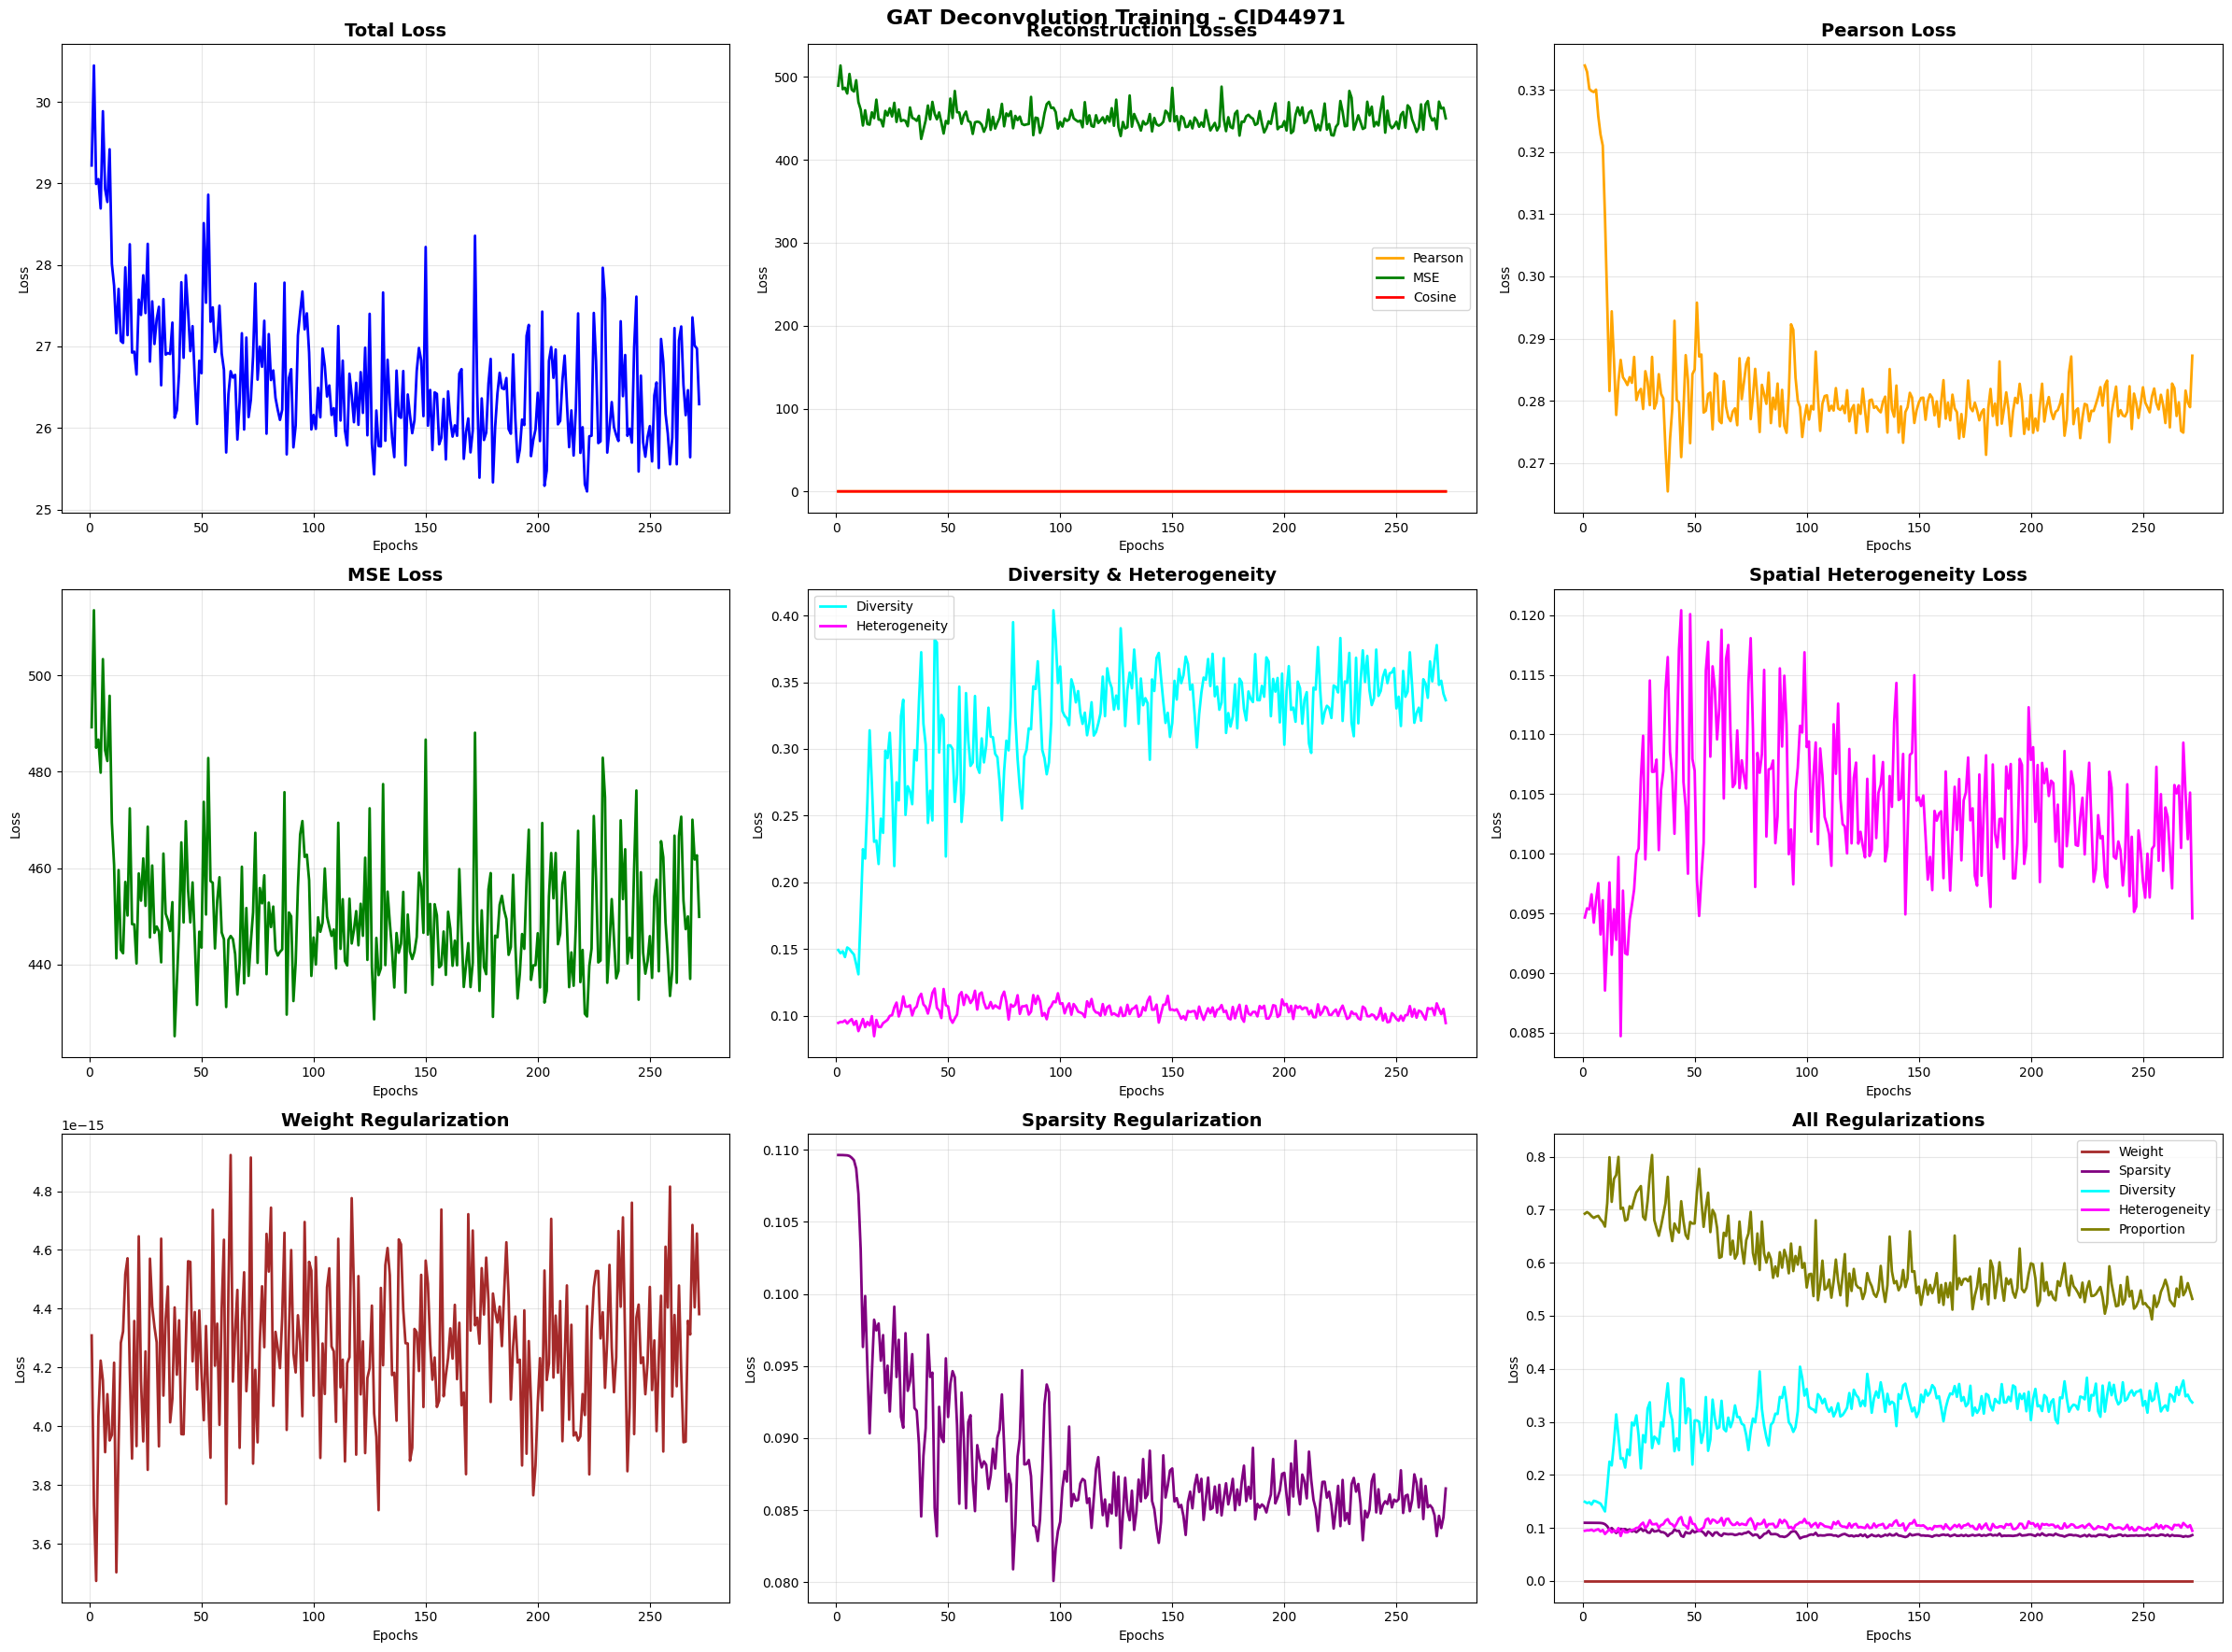

In [ ]:
# k_celltype 影响比较大
%run stage2.py \
    --st_file "/mnt/d/ST_Graduation_Project/database/Wu/CID44971/CID44971_ST.h5ad" \
    --stage1_model_path "./stage1_results/CID44971/final_vae.pth" \
    --output_dir "./stage2_results/CID44971/" \
    --gat_hidden_dim 512 \
    --gat_layers 4 \
    --lr 1e-4 \
    --loss_lambda_mse 0.05 \
    --loss_lambda_cosine 2 \
    --loss_lambda_pearson 2 \
    --loss_lambda_reg 0.1 \
    --loss_lambda_sparse 0.001 \
    --loss_lambda_diversity 0.1 \
    --loss_lambda_hetero 0.1 \
    --loss_lambda_proportion 5 \
    --k_spatial 10 \
    --k_celltype 10 \
    --batch_size 512 \
    --n_epochs 500 \
    --weight_threshold 0.01